<a href="https://colab.research.google.com/github/Rossini-Martyr/CC-Fraud-Detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc, classification_report, confusion_matrix, make_scorer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import OneClassSVM
import xgboost as xgb
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
df_raw = pd.read_csv("/content/creditcard.csv")
df = df_raw.dropna()

Exploratory Data Analysis

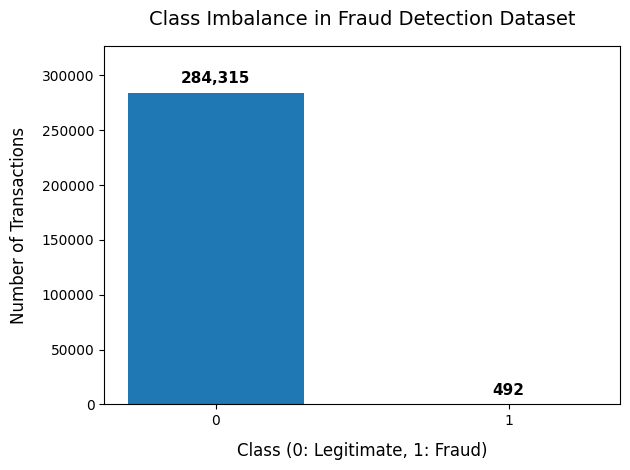

In [ ]:

#Plot chart to show class imbalance in dataset

class_counts = df['Class'].value_counts().sort_values(ascending=False)
plt.bar(class_counts.index.astype(str), class_counts.values, color=['#1f77b4', '#d62728'], width=0.6) #convert from int to string to avoid plotting issues
plt.title('Class Imbalance in Fraud Detection Dataset', fontsize=14, pad=15) #add axis labels
plt.xlabel('Class (0: Legitimate, 1: Fraud)', fontsize=12, labelpad=10)
plt.ylabel('Number of Transactions', fontsize=12, labelpad=10)

for i, v in enumerate(class_counts.values):
    plt.text(i, v + (max(class_counts.values) * 0.02), f"{v:,}", ha='center', va='bottom', fontsize=11, fontweight='bold') #label bar chart

plt.ylim(0, max(class_counts.values) * 1.15)
plt.tight_layout()

In [ ]:
#Create a logistic regression model as a baseline

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y) #use stratified train test split to keep balance

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #fit scaler on the training data only
X_test_scaled = scaler.transform(X_test)

#Train Logistic Regression Model
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42) #balanced class weight to account for imbalance in dataset
lr_model.fit(X_train_scaled, y_train)

y_probs = lr_model.predict_proba(X_test_scaled)[:, 1] #Calculate probabilities for positive class

# Calculate Precision-Recall Curve and AUC
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc_lr = auc(recall, precision)

print(f"Scenario 1: Logistic Regression PR-AUC = {pr_auc_lr:.4f}")

Scenario 1: Logistic Regression PR-AUC = 0.7639


Optimal Threshold (Maximized F1-Score): 1.0000

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



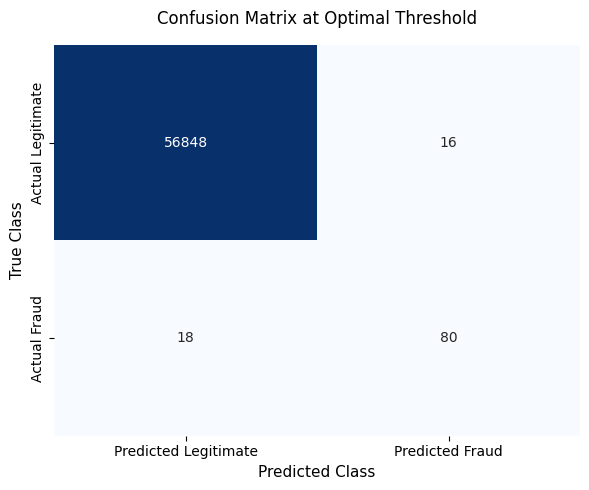

In [ ]:
#Procedure to plot Confusion Matrix

#Find the optimal threshold based on the precision-recall curve calculated previously
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_idx = np.argmax(f1_scores)
best_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (Maximized F1-Score): {best_threshold:.4f}\n")

#Convert probabilities to binary predictions using our custom threshold
y_pred_custom = (y_probs >= best_threshold).astype(int)

#Generate the text-based classification report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_custom, target_names=['Legitimate', 'Fraud']))

#Compute and Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'])

plt.title('Confusion Matrix at Optimal Threshold', fontsize=12, pad=15)
plt.ylabel('True Class', fontsize=11)
plt.xlabel('Predicted Class', fontsize=11)
plt.tight_layout()
plt.show()

Scenario 2: Random Forest PR-AUC = 0.8640

Optimal Threshold (Maximized F1-Score): 0.3000

--- Classification Report (Random Forest) ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.93      0.84      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



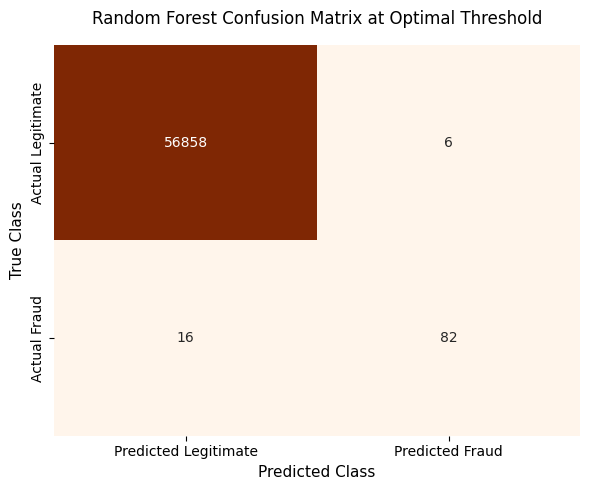

In [ ]:
#Train Random Forest with Class Weighting to account for class imbalance
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

#Predict Probabilities
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

#Calculate Precision-Recall Curve and AUC
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_probs_rf)
pr_auc_rf = auc(recall_rf, precision_rf)

print(f"Scenario 2: Random Forest PR-AUC = {pr_auc_rf:.4f}\n")

#Find the Optimal Threshold (Maximizing F1-Score)
f1_scores_rf = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf + 1e-10)
optimal_idx_rf = np.argmax(f1_scores_rf)
best_threshold_rf = thresholds_rf[optimal_idx_rf]

print(f"Optimal Threshold (Maximized F1-Score): {best_threshold_rf:.4f}\n")

#Generate Predictions and Classification Report
y_pred_rf = (y_probs_rf >= best_threshold_rf).astype(int)
print("--- Classification Report (Random Forest) ---")
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))

#Compute and Plot the Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'])

plt.title('Random Forest Confusion Matrix at Optimal Threshold', fontsize=12, pad=15)
plt.ylabel('True Class', fontsize=11)
plt.xlabel('Predicted Class', fontsize=11)
plt.tight_layout()
plt.show()

Scenario 3: One-Class SVM PR-AUC = 0.3229

Optimal Anomaly Threshold (Maximized F1-Score): -0.3992

--- Classification Report (One-Class SVM) ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.45      0.42      0.43        98

    accuracy                           1.00     56962
   macro avg       0.72      0.71      0.72     56962
weighted avg       1.00      1.00      1.00     56962



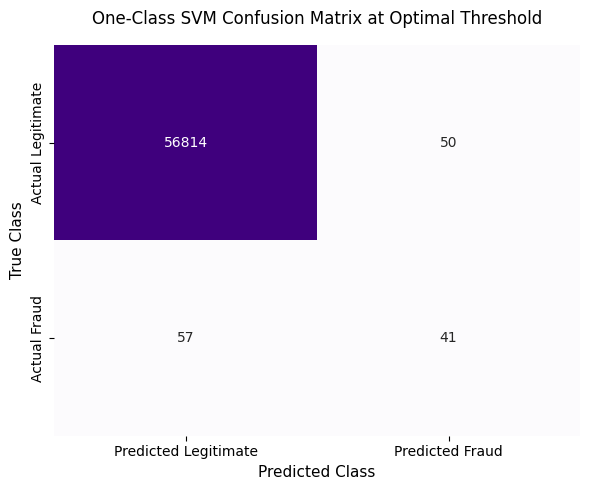

In [ ]:
#Support Vector Machines
#Filter the training data to include only legitimate transactions since SVMs are trained on the majority class
X_train_normal = X_train_scaled[y_train == 0]

# Model training

oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.01) # nu=0.01 implies we expect roughly 1% outliers in our training distribution
oc_svm.fit(X_train_normal)

# Predict Anomaly Scores on the Test Set
# score_samples() returns the raw separating distance.
# Negative values represent anomalies; we invert it so higher scores = higher probability of fraud.
y_scores_svm = -oc_svm.score_samples(X_test_scaled)

# Calculate Precision-Recall Curve and AUC
precision_svm, recall_svm, thresholds_svm = precision_recall_curve(y_test, y_scores_svm)
pr_auc_svm = auc(recall_svm, precision_svm)

print(f"Scenario 3: One-Class SVM PR-AUC = {pr_auc_svm:.4f}\n")

#Find the Optimal Threshold (Maximizing F1-Score)
f1_scores_svm = 2 * (precision_svm * recall_svm) / (precision_svm + recall_svm + 1e-10)
optimal_idx_svm = np.argmax(f1_scores_svm)
best_threshold_svm = thresholds_svm[optimal_idx_svm]

print(f"Optimal Anomaly Threshold (Maximized F1-Score): {best_threshold_svm:.4f}\n")

#Generate Predictions and Classification Report
y_pred_svm = (y_scores_svm >= best_threshold_svm).astype(int)
print("--- Classification Report (One-Class SVM) ---")
print(classification_report(y_test, y_pred_svm, target_names=['Legitimate', 'Fraud']))

#Compute and Plot the Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'])

plt.title('One-Class SVM Confusion Matrix at Optimal Threshold', fontsize=12, pad=15)
plt.ylabel('True Class', fontsize=11)
plt.xlabel('Predicted Class', fontsize=11)
plt.tight_layout()
plt.show()

Calculated scale_pos_weight: 577.29

Scenario 4: XGBoost PR-AUC = 0.8299

Optimal Threshold (Maximized F1-Score): 0.9981

--- Classification Report (XGBoost) ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.95      0.70      0.81        98

    accuracy                           1.00     56962
   macro avg       0.97      0.85      0.90     56962
weighted avg       1.00      1.00      1.00     56962



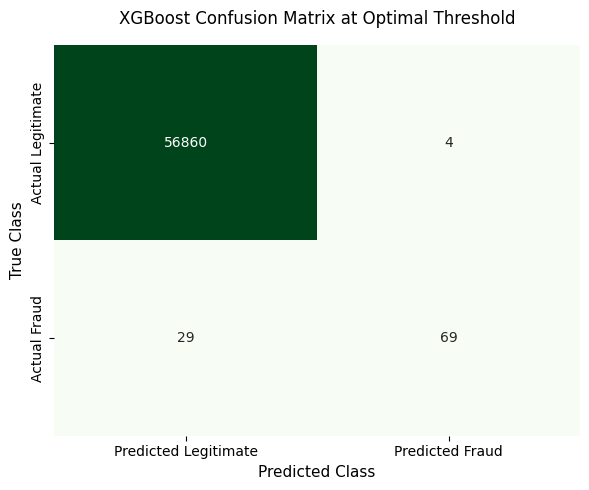

In [ ]:
#XGBoost Model Evaluation
# Calculate the exact scale_pos_weight ratio
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
scale_weight_ratio = neg_count / pos_count

print(f"Calculated scale_pos_weight: {scale_weight_ratio:.2f}\n")

# 2. Train the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_weight_ratio,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

#Predict Probabilities
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall Curve and AUC
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_probs_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

print(f"Scenario 4: XGBoost PR-AUC = {pr_auc_xgb:.4f}\n")

# Solve for the Optimal Threshold (Maximizing F1-Score)
f1_scores_xgb = 2 * (precision_xgb * recall_xgb) / (precision_xgb + recall_xgb + 1e-10)
optimal_idx_xgb = np.argmax(f1_scores_xgb)
best_threshold_xgb = thresholds_xgb[optimal_idx_xgb]

print(f"Optimal Threshold (Maximized F1-Score): {best_threshold_xgb:.4f}\n")

# Generate Predictions and Classification Report
y_pred_xgb = (y_probs_xgb >= best_threshold_xgb).astype(int)
print("--- Classification Report (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud']))

# Compute and Plot the Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'])

plt.title('XGBoost Confusion Matrix at Optimal Threshold', fontsize=12, pad=15)
plt.ylabel('True Class', fontsize=11)
plt.xlabel('Predicted Class', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
#Training Autoencoder
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Filter and Convert Data to PyTorch Tensors
X_train_normal = X_train_scaled[y_train == 0].astype(np.float32)
X_test_tensor = torch.tensor(X_test_scaled.astype(np.float32))

# Create a DataLoader for mini-batch training
train_dataset = TensorDataset(torch.tensor(X_train_normal))
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Define the Autoencoder Architecture in PyTorch
class FraudAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(FraudAutoencoder, self).__init__()
        # Encoder: Compress features down
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()  # Bottleneck layer
        )
        # Decoder: Reconstruct features back
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim) # Linear activation for reconstruction
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

input_dim = X_train_normal.shape[1]
model = FraudAutoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
model.train()
epochs = 20
for epoch in range(epochs):
    for batch in train_loader:
        inputs = batch[0]

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, inputs) # Target is identical to input

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# Evaluation / Inference
model.eval()
with torch.no_grad():
    # Pass the test set through the trained network
    predictions = model(X_test_tensor)
    # Calculate Mean Squared Error (Reconstruction Error) per row
    mse_scores = torch.mean((X_test_tensor - predictions) ** 2, dim=1).numpy()

# Calculate Precision-Recall Curve and AUC
precision_ae, recall_ae, thresholds_ae = precision_recall_curve(y_test, mse_scores)
pr_auc_ae = auc(recall_ae, precision_ae)

print(f"Scenario 5 (PyTorch): Autoencoder PR-AUC = {pr_auc_ae:.4f}\n")

# Find Optimal Threshold (Maximizing F1-Score)
f1_scores_ae = 2 * (precision_ae * recall_ae) / (precision_ae + recall_ae + 1e-10)
optimal_idx_ae = np.argmax(f1_scores_ae)
best_threshold_ae = thresholds_ae[optimal_idx_ae]

print(f"Optimal Reconstruction Error Threshold: {best_threshold_ae:.4f}\n")

# Predictions & Classification Report
y_pred_ae = (mse_scores >= best_threshold_ae).astype(int)
print("--- Classification Report (PyTorch Autoencoder) ---")
print(classification_report(y_test, y_pred_ae, target_names=['Legitimate', 'Fraud']))

Scenario 5 (PyTorch): Autoencoder PR-AUC = 0.2481

Optimal Reconstruction Error Threshold: 15.9590

--- Classification Report (PyTorch Autoencoder) ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.37      0.39      0.38        98

    accuracy                           1.00     56962
   macro avg       0.68      0.69      0.69     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# Define a custom PR-AUC scoring function
# GridSearchCV requires a scorer that returns a single scalar value
def pr_auc_scorer(y_true, y_pred_proba):
    # We evaluate PR-AUC using the probabilities of the positive class (class 1)
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    return auc(recall, precision)

# Wrap it using make_scorer
custom_pr_auc = make_scorer(pr_auc_scorer, response_method='predict_proba')

# Set up the Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced_subsample']
}

#Initialize the Baseline Random Forest Model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring=custom_pr_auc,
    cv=3,
    verbose=2,
    n_jobs=-1
)

print("Starting Cross-Validation Grid Search...")
grid_search.fit(X_train, y_train)

# Extract and Report Best Parameters and Best CV Score
print("\n--- Grid Search Results ---")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Stratified CV PR-AUC Score: {grid_search.best_score_:.4f}\n")

#Evaluate the Best Model on the Unseen Test Set
best_rf_model = grid_search.best_estimator_
y_probs_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

#Calculate final test PR-AUC
final_precision, final_recall, _ = precision_recall_curve(y_test, y_probs_best_rf)
final_pr_auc = auc(final_recall, final_precision)

print(f"Final Holdout Test PR-AUC Score: {final_pr_auc:.4f}")

Starting Cross-Validation Grid Search...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

--- Grid Search Results ---
Best Hyperparameters: {'class_weight': 'balanced_subsample', 'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 100}
Best Stratified CV PR-AUC Score: 0.7986

Final Holdout Test PR-AUC Score: 0.8086


In [ ]:
# XGBoost hyperparameter tuning
param_grid_xgb = {
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [scale_weight_ratio]
}

#Initialize the Baseline XGBoost Classifier
xgb_base = xgb.XGBClassifier(
    n_estimators=100,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

#Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring=custom_pr_auc,
    cv=3,
    verbose=2,
    n_jobs=-1
)

#Execute the Grid Search on the Training Set
print("Starting XGBoost Cross-Validation Grid Search...")
grid_search_xgb.fit(X_train, y_train)

#Report Best Parameters and Best CV Score
print("\n--- XGBoost Grid Search Results ---")
print(f"Best Hyperparameters: {grid_search_xgb.best_params_}")
print(f"Best Stratified CV PR-AUC Score: {grid_search_xgb.best_score_:.4f}\n")

#Evaluate the Best Model on the Unseen Test Set
best_xgb_model = grid_search_xgb.best_estimator_
y_probs_best_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Calculate final holdout test PR-AUC
final_precision_xgb, final_recall_xgb, _ = precision_recall_curve(y_test, y_probs_best_xgb)
final_pr_auc_xgb = auc(final_recall_xgb, final_precision_xgb)

print(f"Final XGBoost Holdout Test PR-AUC Score: {final_pr_auc_xgb:.4f}")

Starting XGBoost Cross-Validation Grid Search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

--- XGBoost Grid Search Results ---
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 6, 'scale_pos_weight': np.float64(577.2868020304569), 'subsample': 1.0}
Best Stratified CV PR-AUC Score: 0.8297

Final XGBoost Holdout Test PR-AUC Score: 0.8650


In [ ]:
#Collate the results into a table for easy comparison
results_data = {
    "Scenario": [1, 2, 3, 4, 5, 6, 7],
    "Model Architecture": [
        "Logistic Regression (Balanced)",
        "Base Random Forest (Balanced Subsample)",
        "One-Class SVM (Anomaly Detection)",
        "Base XGBoost (scale_pos_weight)",
        "Autoencoder (PyTorch Unsupervised)",
        "Cross-Validated Random Forest (Optimized)",
        "Cross-Validated XGBoost (Optimized)"
    ],
    "Learning Type": [
        "Supervised", "Supervised", "Unsupervised",
        "Supervised", "Unsupervised", "Supervised", "Supervised"
    ],
    "Scale Required?": [
        "Yes", "No", "Yes", "No", "Yes", "No", "No"
    ],
    "PR-AUC Score": [
        pr_auc_lr,          # Scenario 1: Logistic Regression
        pr_auc_rf,          # Scenario 2: Base Random Forest
        pr_auc_svm,         # Scenario 3: One-Class SVM
        pr_auc_xgb,         # Scenario 4: Base XGBoost
        pr_auc_ae,          # Scenario 5: PyTorch Autoencoder
        final_pr_auc,       # Scenario 6: Holdout Test PR-AUC from RF GridSearch
        final_pr_auc_xgb    # Scenario 7: Holdout Test PR-AUC from XGBoost GridSearch
    ]
}

#Create DataFrame
df_summary = pd.DataFrame(results_data)

#Sort by performance (highest PR-AUC first)
df_summary_sorted = df_summary.sort_values(by="PR-AUC Score", ascending=False, na_position='last')

#Display the formatted table
print(df_summary_sorted.to_markdown(index=False))

|   Scenario | Model Architecture                        | Learning Type   | Scale Required?   |   PR-AUC Score |
|-----------:|:------------------------------------------|:----------------|:------------------|---------------:|
|          7 | Cross-Validated XGBoost (Optimized)       | Supervised      | No                |       0.865028 |
|          2 | Base Random Forest (Balanced Subsample)   | Supervised      | No                |       0.864048 |
|          4 | Base XGBoost (scale_pos_weight)           | Supervised      | No                |       0.829893 |
|          6 | Cross-Validated Random Forest (Optimized) | Supervised      | No                |       0.808603 |
|          1 | Logistic Regression (Balanced)            | Supervised      | Yes               |       0.763894 |
|          3 | One-Class SVM (Anomaly Detection)         | Unsupervised    | Yes               |       0.322874 |
|          5 | Autoencoder (PyTorch Unsupervised)        | Unsupervised    | Yes        